In [2]:
from PIL import Image
import numpy as np

# Open the image file
img = Image.open('/mnt/c/Users/dmmsp/Projects/Hurricane-Explainer-Engine/data/cloudCover/clouds_lmh_2017080100.png')

# Convert the image to a NumPy array
img_array = np.array(img)

# Extract the red channel (assuming the image is RGB or RGBA)
# The red channel is typically the first channel (index 0)
red_channel = img_array[:, :, 0]

# Scale the red channel data to the range [0, 1]
# Assuming the original data is in the range [0, 255] (common for image data)
scaled_red_channel = red_channel / 255.0

# Display the shape of the scaled array and some values
print("Shape of the scaled red channel array:", scaled_red_channel.shape)
print("Scaled red channel array (first 5x5):")
display(scaled_red_channel[:5, :5])

Shape of the scaled red channel array: (721, 1440)
Scaled red channel array (first 5x5):


array([[0.98039216, 0.98039216, 0.98039216, 0.98039216, 0.98039216],
       [0.93333333, 0.9372549 , 0.9372549 , 0.9372549 , 0.9372549 ],
       [0.97254902, 0.97254902, 0.97254902, 0.97254902, 0.97647059],
       [0.99607843, 1.        , 1.        , 1.        , 1.        ],
       [1.        , 1.        , 1.        , 1.        , 1.        ]])

In [3]:
scaled_red_channel = np.flipud(scaled_red_channel)

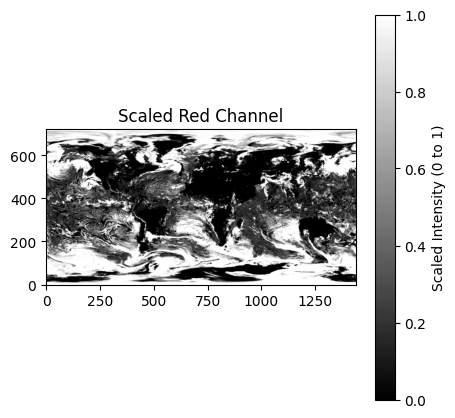

In [5]:
import matplotlib.pyplot as plt

# Create a 2D plot from the scaled red channel array
plt.figure(figsize=(5, 5))
plt.imshow(scaled_red_channel, cmap='gray', origin='lower')
plt.title('Scaled Red Channel')
plt.colorbar(label='Scaled Intensity (0 to 1)')
plt.show()

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, FloatSlider

lowBreakPoint = 0.75
highBreakPoint = 0.95

def update_plot(lowBreakPoint, highBreakPoint):
    # Create an empty color image array with the same shape as the scaled red channel, but with 3 channels for RGB
    color_image = np.zeros((scaled_red_channel.shape[0], scaled_red_channel.shape[1], 3), dtype=np.uint8)

    # Assign colors based on the thresholds
    # Red for values less than lowBreakPoint
    color_image[scaled_red_channel < lowBreakPoint] = [255, 0, 0]

    # Green for values between lowBreakPoint and highBreakPoint
    color_image[(scaled_red_channel >= lowBreakPoint) & (scaled_red_channel < highBreakPoint)] = [0, 255, 0]

    # Blue for values greater than or equal to highBreakPoint
    color_image[scaled_red_channel >= highBreakPoint] = [0, 0, 255]

    # Create a 2D plot from the color image array
    plt.figure(figsize=(10, 10))
    plt.imshow(color_image, origin='lower')
    plt.title('Color coded based on scaled red channel')
    plt.show()

# Create sliders for lowBreakPoint and highBreakPoint
low_slider = FloatSlider(min=0.0, max=1.0, step=0.01, value=lowBreakPoint, description='Low Breakpoint:')
high_slider = FloatSlider(min=0.0, max=1.0, step=0.01, value=highBreakPoint, description='High Breakpoint:')

# Use interact to link the sliders to the update_plot function
interact(update_plot, lowBreakPoint=low_slider, highBreakPoint=high_slider)

interactive(children=(FloatSlider(value=0.75, description='Low Breakpoint:', max=1.0, step=0.01), FloatSlider(…

<function __main__.update_plot(lowBreakPoint, highBreakPoint)>

In [8]:
def get_neighbors(arr, row_col):
    """
    Returns the 8 neighbors of a given cell in a 2D array in clockwise order.

    Args:
        arr (np.ndarray): The input 2D NumPy array.
        row_col (tuple): A tuple (row, col) representing the cell's indices.

    Returns:
        tuple: A tuple containing the indices of the 8 neighbors in clockwise order,
               starting from North and ending at Northwest. None is returned for
               neighbors that do not exist.
    """
    if row_col is None:
        return (None, None, None, None, None, None, None, None)

    rows, cols = arr.shape
    row, col = row_col

    neighbors = []

    # Define the relative indices for the 8 neighbors in clockwise order
    # (row_offset, col_offset)
    neighbor_offsets = [
        (-1, 0),  # North
        (-1, 1),  # Northeast
        (0, 1),   # East
        (1, 1),   # Southeast
        (1, 0),   # South
        (1, -1),  # Southwest
        (0, -1),  # West
        (-1, -1)  # Northwest
    ]

    for row_offset, col_offset in neighbor_offsets:
        neighbor_row = row + row_offset
        neighbor_col = col + col_offset

        # Check if the neighbor is within the array bounds
        if 0 <= neighbor_row < rows and 0 <= neighbor_col < cols:
            neighbors.append((neighbor_row, neighbor_col))
        else:
            neighbors.append(None)

    return tuple(neighbors)

# Example usage (assuming scaled_red_channel is your 2D array)
# You can replace (row, col) with the actual indices you want to test
# test_row_col = (100, 200)
# neighbor_indices = get_neighbors(scaled_red_channel, test_row_col)
# print(f"Neighbors of {test_row_col}: {neighbor_indices}")

# Example with None input
# neighbor_indices_none = get_neighbors(scaled_red_channel, None)
# print(f"Neighbors of None: {neighbor_indices_none}")

In [9]:
# Define a constant for the cloud core threshold
CLOUD_CORE_THRESHOLD = 0.95

# Get the indices where the scaled red channel is greater than the threshold
cloud_core_indices = np.where(scaled_red_channel > CLOUD_CORE_THRESHOLD)

# Combine the row and column indices into a list of tuples
cloud_core_locations = list(zip(cloud_core_indices[0], cloud_core_indices[1]))

# Display the number of cloud core locations found and the first few locations
print(f"Number of cloud core locations: {len(cloud_core_locations)}")
print("First 10 cloud core locations (row, col):")
display(cloud_core_locations[:10])

Number of cloud core locations: 258472
First 10 cloud core locations (row, col):


[(np.int64(0), np.int64(0)),
 (np.int64(0), np.int64(1)),
 (np.int64(0), np.int64(2)),
 (np.int64(0), np.int64(3)),
 (np.int64(0), np.int64(4)),
 (np.int64(0), np.int64(5)),
 (np.int64(0), np.int64(6)),
 (np.int64(0), np.int64(7)),
 (np.int64(0), np.int64(8)),
 (np.int64(0), np.int64(9))]

BFS complete.
Number of visited locations: 319185
Number of neighboring cloud locations found: 60713


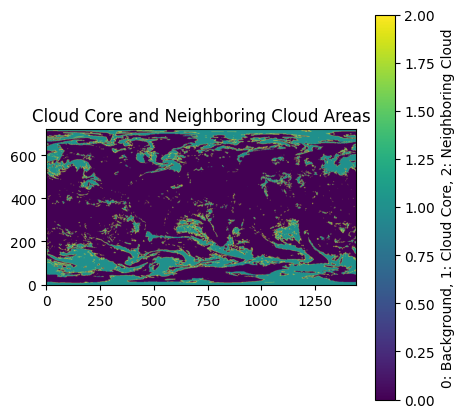

Unique values and their counts in the result array:


{np.uint8(0): np.int64(719055),
 np.uint8(1): np.int64(258472),
 np.uint8(2): np.int64(60713)}

In [10]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt

# Define constants
CLOUD_CORE_THRESHOLD = 0.95
NEIGHBORING_CLOUD_THRESHOLD = 0.75

# Assuming scaled_red_channel is already loaded and available

# Get the indices where the scaled red channel is greater than the cloud core threshold
cloud_core_indices = np.where(scaled_red_channel > CLOUD_CORE_THRESHOLD)

# Combine the row and column indices into a list of tuples
cloud_core_locations = list(zip(cloud_core_indices[0], cloud_core_indices[1]))

# Initialize the queue with cloud_core_locations
queue = deque(cloud_core_locations)

# Initialize an empty set for visited locations
visited = set(cloud_core_locations) # Mark initial cloud cores as visited

# Initialize the result array with the same shape as scaled_red_channel, filled with zeros
result_array = np.zeros_like(scaled_red_channel, dtype=np.uint8)

# Mark initial cloud cores in the result array with 1
for row, col in cloud_core_locations:
    result_array[row, col] = 1

# Implement BFS loop
while queue:
    # Dequeue a location
    current_row, current_col = queue.popleft()

    # Get the 8 neighbors of the current location
    neighbors = get_neighbors(scaled_red_channel, (current_row, current_col))

    # Process neighbors
    for neighbor in neighbors:
        # Check if the neighbor is valid (not None)
        if neighbor is not None:
            neighbor_row, neighbor_col = neighbor

            # Check if the neighbor has not been visited
            if neighbor not in visited:
                # Check if the cloud cover at the neighbor's location is greater than the threshold
                if scaled_red_channel[neighbor_row, neighbor_col] > NEIGHBORING_CLOUD_THRESHOLD:
                    # Enqueue the neighbor
                    # queue.append(neighbor)
                    # Add the neighbor to the visited set
                    visited.add(neighbor)
                    # Set the corresponding element in result_array to 2
                    result_array[neighbor_row, neighbor_col] = 2

print("BFS complete.")
print("Number of visited locations:", len(visited))
print("Number of neighboring cloud locations found:", np.sum(result_array == 2))


# Display the result array
plt.figure(figsize=(5, 5))
plt.imshow(result_array, cmap='viridis', origin='lower') # Using viridis colormap to distinguish 0, 1, and 2
plt.title('Cloud Core and Neighboring Cloud Areas')
plt.colorbar(label='0: Background, 1: Cloud Core, 2: Neighboring Cloud')
plt.show()

# Display unique values and their counts in the result array
unique, counts = np.unique(result_array, return_counts=True)
print("Unique values and their counts in the result array:")
display(dict(zip(unique, counts)))

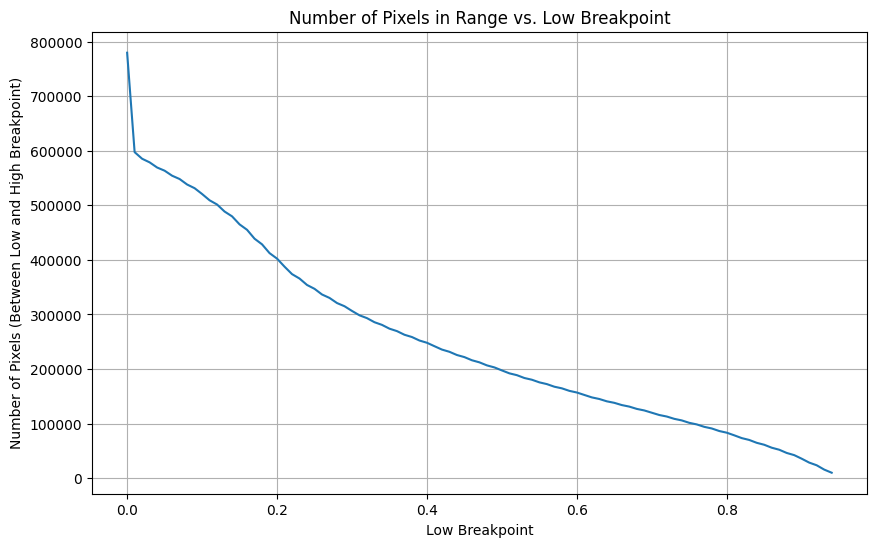

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Define the constant high breakpoint
highBreakPoint_constant = 0.95

# Define the range of low breakpoints to test
lowBreakPoints_to_test = np.arange(0, highBreakPoint_constant, 0.01) # Vary lowBreakPoint from 0 to 0.94 with a step of 0.01

# List to store the counts of pixels in the specified range
green_pixel_counts = []

# Iterate through each low breakpoint
for lowBreakPoint in lowBreakPoints_to_test:
    # Calculate the number of pixels where scaled_red_channel is between lowBreakPoint and highBreakPoint_constant
    count = np.sum((scaled_red_channel >= lowBreakPoint) & (scaled_red_channel < highBreakPoint_constant))
    green_pixel_counts.append(count)

# Create the line graph
plt.figure(figsize=(10, 6))
plt.plot(lowBreakPoints_to_test, green_pixel_counts)
plt.xlabel('Low Breakpoint')
plt.ylabel('Number of Pixels (Between Low and High Breakpoint)')
plt.title('Number of Pixels in Range vs. Low Breakpoint')
plt.grid(True)
plt.show()


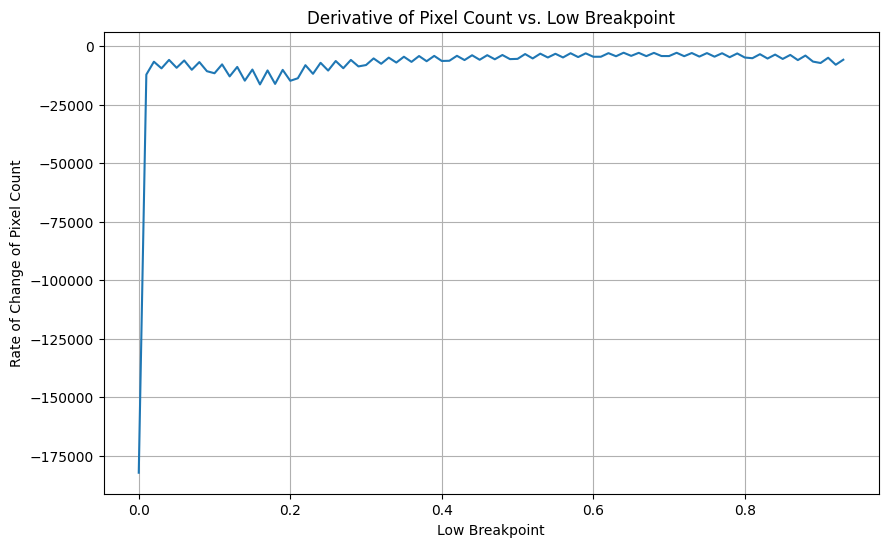

First 10 derivative values:


array([-182257,  -12107,   -6603,   -9440,   -5827,   -9196,   -6074,
        -10046,   -6761,  -10659])

In [12]:
# Calculate the derivative of the green pixel counts with respect to the low breakpoints
# Use np.diff to calculate the difference between consecutive elements
# The result will have one less element than the original arrays
derivative_counts = np.diff(green_pixel_counts)
derivative_lowBreakPoints = lowBreakPoints_to_test[:-1] # The x-values for the derivative are the starting points of the intervals

# Create the line graph of the derivative
plt.figure(figsize=(10, 6))
plt.plot(derivative_lowBreakPoints, derivative_counts)
plt.xlabel('Low Breakpoint')
plt.ylabel('Rate of Change of Pixel Count')
plt.title('Derivative of Pixel Count vs. Low Breakpoint')
plt.grid(True)
plt.show()

# Display the first few derivative values
print("First 10 derivative values:")
display(derivative_counts[:10])

In [13]:
import xarray as xr

grib_path = '/home/dmmsp/Projects/rawEra5Data/cloudCoverHumidityWaterAndIceTemperatureWindDirection.grib'
index_path = '/home/dmmsp/Projects/rawEra5Data/full_file.idx'
ds = xr.open_dataset(
    grib_path,
    engine='cfgrib',
    backend_kwargs={
        "indexpath": index_path
    }
)
print(ds)

<xarray.Dataset> Size: 146GB
Dimensions:        (time: 1464, isobaricInhPa: 3, latitude: 721, longitude: 1440)
Coordinates:
    number         int64 8B ...
  * time           (time) datetime64[ns] 12kB 2017-08-01 ... 2017-09-30T23:00:00
    step           timedelta64[ns] 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 24B 850.0 500.0 250.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time     (time) datetime64[ns] 12kB ...
Data variables:
    cc             (time, isobaricInhPa, latitude, longitude) float32 18GB ...
    r              (time, isobaricInhPa, latitude, longitude) float32 18GB ...
    ciwc           (time, isobaricInhPa, latitude, longitude) float32 18GB ...
    clwc           (time, isobaricInhPa, latitude, longitude) float32 18GB ...
    t              (time, isobaricInhPa, latitude, longitude) float32 18GB ...
    u              (time, isobaricI

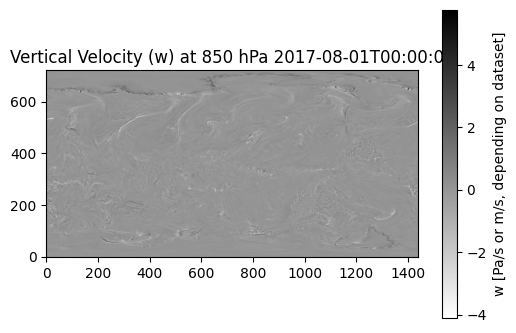

In [14]:
import matplotlib.pyplot as plt

# Select time and level
time_sel = "2017-08-01T00:00:00"
level_sel = 850

w_850 = ds['w'].sel(time=time_sel, isobaricInhPa=level_sel)

plt.figure(figsize=(6, 4))
plt.imshow(w_850, cmap='gray_r', origin='lower')  # gray_r so white = lift (positive updraft)
plt.title(f'Vertical Velocity (w) at {level_sel} hPa {time_sel}')
plt.colorbar(label='w [Pa/s or m/s, depending on dataset]')
plt.show()


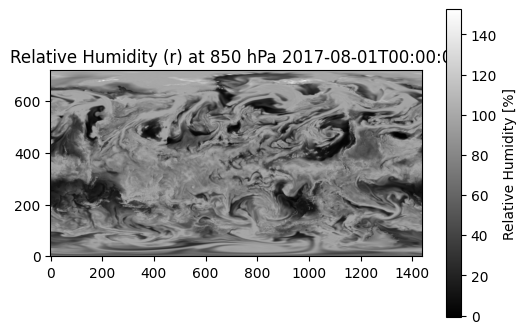

In [15]:
r_850 = ds['r'].sel(time=time_sel, isobaricInhPa=level_sel)

plt.figure(figsize=(6, 4))
plt.imshow(r_850, cmap='gray', origin='lower')
plt.title(f'Relative Humidity (r) at {level_sel} hPa {time_sel}')
plt.colorbar(label='Relative Humidity [%]')
plt.show()


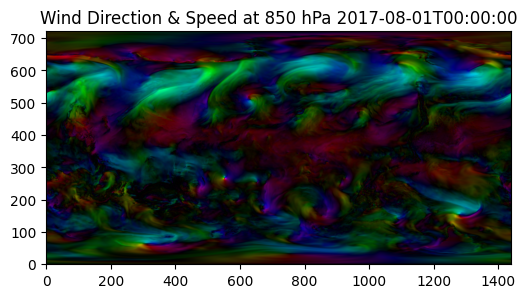

In [16]:
import numpy as np

u_850 = ds['u'].sel(time=time_sel, isobaricInhPa=level_sel)
v_850 = ds['v'].sel(time=time_sel, isobaricInhPa=level_sel)

# Compute speed and direction (in radians)
speed = np.sqrt(u_850**2 + v_850**2)
direction = np.arctan2(v_850, u_850)  # angle from x-axis

# Map direction (−π..π) to 0..1 for hue, speed to 0..1 for value
h = (direction + np.pi) / (2 * np.pi)
v_val = (speed / speed.max()).clip(0, 1)
s = np.ones_like(h)

# Convert HSV → RGB
import matplotlib.colors as mcolors
rgb = mcolors.hsv_to_rgb(np.stack([h, s, v_val], axis=-1))

plt.figure(figsize=(6, 4))
plt.imshow(rgb, origin='lower')
plt.title(f'Wind Direction & Speed at {level_sel} hPa {time_sel}')
plt.show()


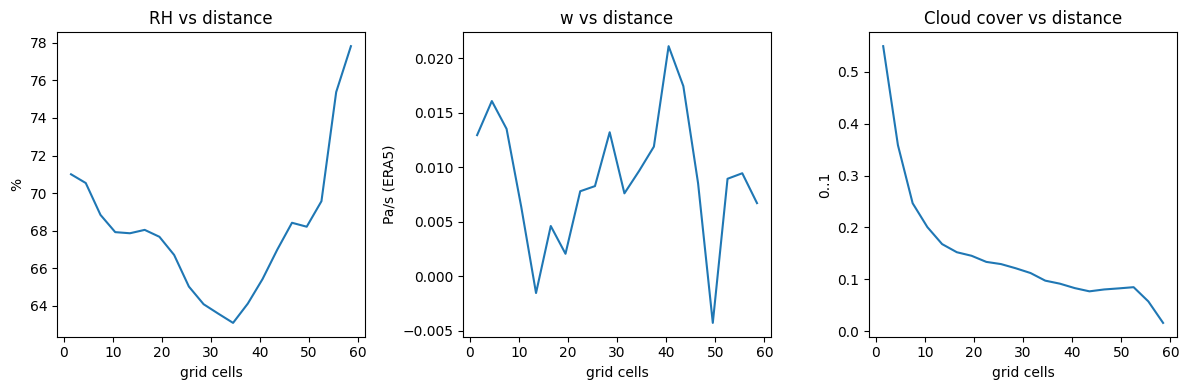

Correlations (background only):
RH          n= 719055  pearson=+0.027  spearman=-0.001
w           n= 719055  pearson=+0.009  spearman=+0.003
windspeed   n= 719055  pearson=-0.109  spearman=-0.142
conv        n= 719055  pearson=+0.005  spearman=+0.001

Regression coefficients (intercept, RH, w, conv[, windspeed]):
[0.23361211 0.00028614 0.01325525 0.00150018]
R² = 0.001


In [19]:
import numpy as np
import scipy.ndimage as ndi
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# -----------------------------
# 0) Pull numpy arrays from your xarray fields (assumes matching grid/shape)
# -----------------------------
u = np.asarray(u_850)
v = np.asarray(v_850)
r = np.asarray(r_850)      # [%]
w = np.asarray(w_850)      # Pa/s (ERA5 convention: negative = ascent)
cloud = np.asarray(scaled_red_channel)  # 0..1
labels = np.asarray(result_array, dtype=np.uint8)  # 0 bg, 1 core, 2 neighbor

# (Optional) land–sea mask, if you have it:
# ocean_mask = (np.asarray(lsm) < 0.5)

# -----------------------------
# 1) Masks
# -----------------------------
core = (labels == 1)
neighbor = (labels == 2)
bg = (labels == 0)  # analyze only non-core & non-neighbor pixels

# If you want ocean-only background:
# bg &= ocean_mask

# -----------------------------
# 2) Distance from nearest core, in grid cells
# -----------------------------
dist = ndi.distance_transform_edt(~core)  # 0 on cores, grows outward

# -----------------------------
# 3) Derived fields
# -----------------------------
windspeed = np.hypot(u, v)

def divergence(u, v):
    # centered differences, assumes unit grid spacing (ok for correlation shape)
    dudx = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / 2.0
    dvdy = (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / 2.0
    return dudx + dvdy

div = divergence(u, v)
conv = -div  # convergence proxy (+ means converging low-level flow)

# -----------------------------
# 4) Radial profiles away from cores (background only)
# -----------------------------
def binned_profile(var, dist, mask, bins):
    x = dist[mask].ravel()
    y = var[mask].ravel()
    idx = np.digitize(x, bins) - 1
    centers = 0.5*(bins[:-1] + bins[1:])
    mean, med, q25, q75, n = [], [], [], [], []
    for i in range(len(bins)-1):
        sel = (idx == i)
        if np.any(sel):
            yy = y[sel]
            mean.append(np.nanmean(yy))
            med.append(np.nanmedian(yy))
            q25.append(np.nanpercentile(yy, 25))
            q75.append(np.nanpercentile(yy, 75))
            n.append(int(sel.sum()))
        else:
            mean.append(np.nan); med.append(np.nan); q25.append(np.nan); q75.append(np.nan); n.append(0)
    return centers, np.array(mean), np.array(med), np.array(q25), np.array(q75), np.array(n)

bins = np.arange(0, 61, 3)  # 0–60 grid cells, 3-cell steps
fields = dict(cloud=cloud, RH=r, w=w, windspeed=windspeed, conv=conv)
profiles = {}

for k, arr in fields.items():
    c, m, md, p25, p75, n = binned_profile(arr, dist, bg, bins)
    profiles[k] = dict(center=c, mean=m, median=md, p25=p25, p75=p75, count=n)

# -----------------------------
# 5) Quick-look plots (distance vs mean)
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.plot(profiles['RH']['center'], profiles['RH']['mean']); plt.title('RH vs distance'); plt.xlabel('grid cells'); plt.ylabel('%')
plt.subplot(1,3,2); plt.plot(profiles['w']['center'], profiles['w']['mean']); plt.title('w vs distance'); plt.xlabel('grid cells'); plt.ylabel('Pa/s (ERA5)')
plt.subplot(1,3,3); plt.plot(profiles['cloud']['center'], profiles['cloud']['mean']); plt.title('Cloud cover vs distance'); plt.xlabel('grid cells'); plt.ylabel('0..1')
plt.tight_layout(); plt.show()

# -----------------------------
# 6) Pixelwise correlations on the non-core field
# -----------------------------
def corr_report(y, **vars_dict):
    out = {}
    yy = y[bg].ravel()
    for name, arr in vars_dict.items():
        xx = arr[bg].ravel()
        ok = np.isfinite(xx) & np.isfinite(yy)
        if ok.sum() < 50:
            out[name] = dict(n=int(ok.sum()), pearson=np.nan, spearman=np.nan)
        else:
            out[name] = dict(
                n=int(ok.sum()),
                pearson=pearsonr(xx[ok], yy[ok])[0],
                spearman=spearmanr(xx[ok], yy[ok]).correlation
            )
    return out

corrs = corr_report(cloud, RH=r, w=w, windspeed=windspeed, conv=conv)
print("Correlations (background only):")
for k, d in corrs.items():
    print(f"{k:10s}  n={d['n']:7d}  pearson={d['pearson']:+.3f}  spearman={d['spearman']:+.3f}")

# -----------------------------
# 7) Multiple linear regression: cloud ~ RH + w + conv (+ windspeed)
# -----------------------------
import numpy.linalg as LA

yy = cloud[bg].ravel()
X = np.column_stack([
    np.ones_like(yy),
    r[bg].ravel(),
    w[bg].ravel(),
    conv[bg].ravel(),
    # windspeed[bg].ravel(),  # uncomment to include
])

ok = np.all(np.isfinite(X), axis=1) & np.isfinite(yy)
beta, *_ = LA.lstsq(X[ok], yy[ok], rcond=None)
yhat = X[ok] @ beta
ss_res = np.sum((yy[ok] - yhat)**2)
ss_tot = np.sum((yy[ok] - yy[ok].mean())**2)
r2 = 1 - ss_res/ss_tot

print("\nRegression coefficients (intercept, RH, w, conv[, windspeed]):")
print(beta)
print(f"R² = {r2:.3f}")

# Helpful sign reminders for interpretation:
# - ERA5 w: negative = ascent, positive = subsidence.
#   If cloud correlates NEGATIVELY with w, that's "more cloud with more ascent".
# - conv: positive = converging low-level flow (tends to favor cloud).
# - RH: expect positive relationship with cloud.


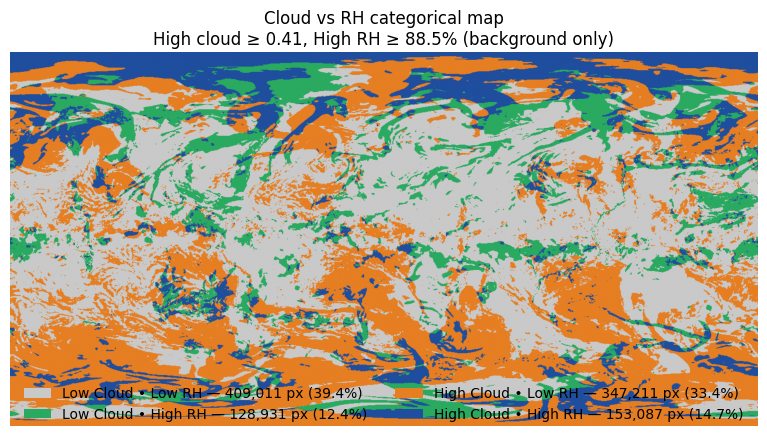

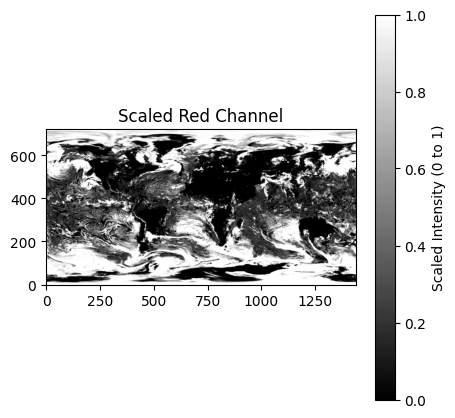

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import scipy.ndimage as ndi

# --- inputs from your notebook ---
cloud  = np.asarray(scaled_red_channel)            # 0..1
labels = np.asarray(result_array, dtype=np.uint8)  # 0 bg, 1 core, 2 neighbor
RH     = np.asarray(r_850)                         # [%], same grid
# Optional land-sea mask (0 ocean, 1 land):
# ocean_mask = (np.asarray(lsm) < 0.5)

# --- analysis domain ---
bg = (labels == 0)
# If you want ocean-only:
# bg &= ocean_mask

# --- choose thresholds ---
USE_QUANTILES = True

if USE_QUANTILES:
    # robust thresholds from background pixels
    cloud_thr = np.nanpercentile(cloud[bg], 75)   # top quartile = “high cloud”
    rh_thr    = np.nanpercentile(RH[bg], 75)      # top quartile = “high RH”
else:
    cloud_thr = 0.75   # fixed: “high cloud”
    rh_thr    = 70.0   # fixed: “high RH” in %

# --- build categories (0..3) only on bg pixels; keep others transparent later ---
# 0: low cloud, low RH      (LL) → light gray
# 1: low cloud, high RH     (LH) → green
# 2: high cloud, low RH     (HL) → orange
# 3: high cloud, high RH    (HH) → deep blue
cat = np.full(cloud.shape, -1, dtype=np.int8)  # -1 = not plotted (cores/neighbors)
low_cloud = cloud < cloud_thr
high_cloud = ~low_cloud
low_rh = RH < rh_thr
high_rh = ~low_rh

# cat[np.where(bg & low_cloud & low_rh)]  = 0
# cat[np.where(bg & low_cloud & high_rh)] = 1
# cat[np.where(bg & high_cloud & low_rh)] = 2
# cat[np.where(bg & high_cloud & high_rh)] = 3

cat[np.where(low_cloud & low_rh)]  = 0
cat[np.where(low_cloud & high_rh)] = 1
cat[np.where(high_cloud & low_rh)] = 2
cat[np.where(high_cloud & high_rh)] = 3

# --- color map (colorblind-friendly, high contrast)
cmap = ListedColormap([
    "#C9C9C9",  # 0 LL  light gray       (dry & clear)
    "#2AAA60",  # 1 LH  green            (humid but low cloud)
    "#E67E22",  # 2 HL  orange           (cloudy but drier)
    "#1F4E9E",  # 3 HH  deep blue        (wet & cloudy)
])

# --- compute class counts for legend
labels_text = [
    "Low Cloud • Low RH",
    "Low Cloud • High RH",
    "High Cloud • Low RH",
    "High Cloud • High RH",
]
counts = [(cat == i).sum() for i in range(4)]
total_bg = sum(counts)
perc = [100*cnt/total_bg if total_bg>0 else 0 for cnt in counts]

# --- make figure
plt.figure(figsize=(8.5, 4.8))

# background: show your gray cloud image faintly for context (optional)
plt.imshow(cloud, origin="lower", cmap="gray", alpha=0.25)

# categorical overlay (mask out cores/neighbors by setting alpha=0 for -1)
# we’ll map -1 to transparent by plotting only valid categories
valid = cat >= 0
show = np.ma.masked_where(~valid, cat)
# im = plt.imshow(show, origin="lower", cmap=cmap, vmin=-0.5, vmax=3.5)
im = plt.imshow(cat, origin="lower", cmap=cmap, vmin=-0.5, vmax=3.5)

plt.title(
    "Cloud vs RH categorical map\n"
    f"High cloud ≥ {cloud_thr:.2f}, High RH ≥ {rh_thr:.1f}% (background only)"
)
plt.axis("off")

# custom legend with counts and %
from matplotlib.patches import Patch
handles = [
    Patch(facecolor=cmap.colors[i], edgecolor="none",
          label=f"{labels_text[i]} — {counts[i]:,} px ({perc[i]:.1f}%)")
    for i in range(4)
]
plt.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=2, frameon=False)

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt

# Create a 2D plot from the scaled red channel array
plt.figure(figsize=(5, 5))
plt.imshow(scaled_red_channel, cmap='gray', origin='lower')
plt.title('Scaled Red Channel')
plt.colorbar(label='Scaled Intensity (0 to 1)')
plt.show()

In [38]:
import xarray as xr

grib_path = '/mnt/c/Users/dmmsp/Downloads/singleHourRHAtMultiplePressureLevels.grib'
rh_DS = xr.open_dataset(
    grib_path,
    engine='cfgrib',
)
print(rh_DS)

<xarray.Dataset> Size: 29MB
Dimensions:        (isobaricInhPa: 7, latitude: 721, longitude: 1440)
Coordinates:
    number         int64 8B ...
    time           datetime64[ns] 8B ...
    step           timedelta64[ns] 8B ...
  * isobaricInhPa  (isobaricInhPa) float64 56B 1e+03 975.0 950.0 ... 875.0 850.0
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time     datetime64[ns] 8B ...
Data variables:
    r              (isobaricInhPa, latitude, longitude) float32 29MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-28T13:59 GRIB to CDM+CF via cfgrib-0.9.1...


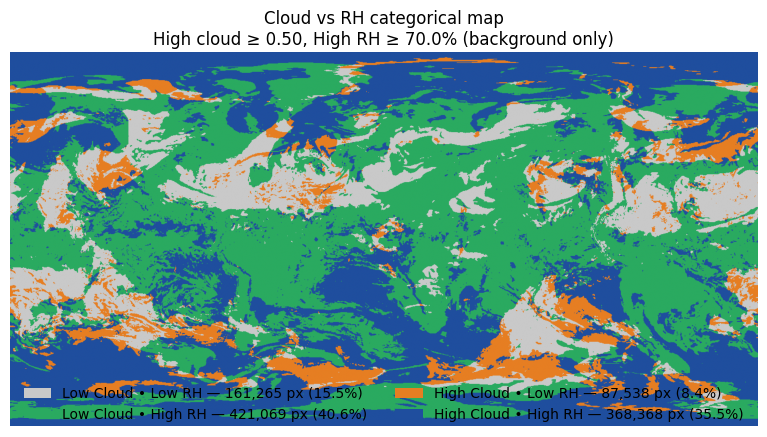

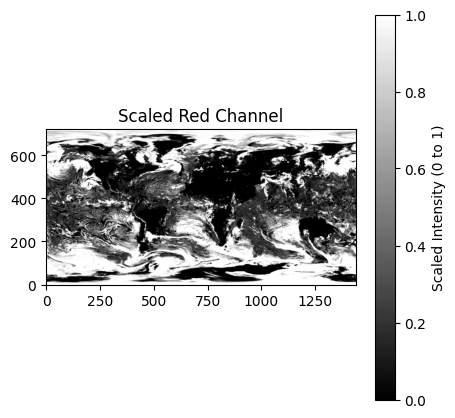

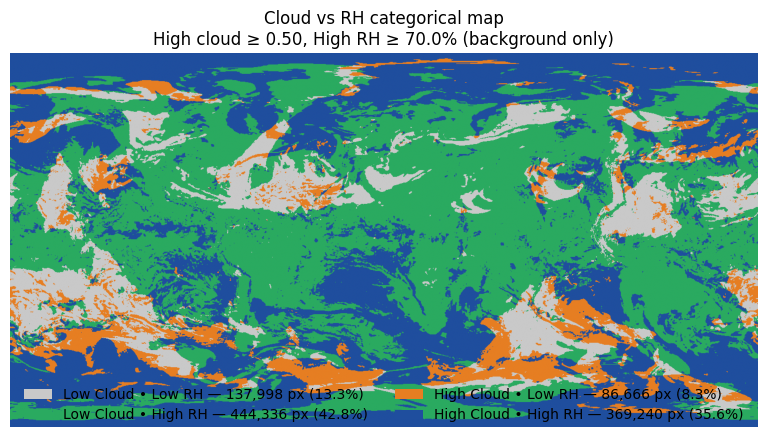

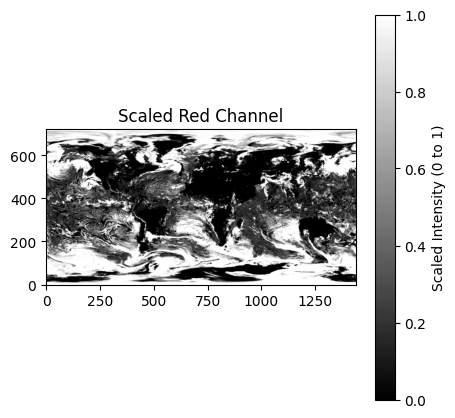

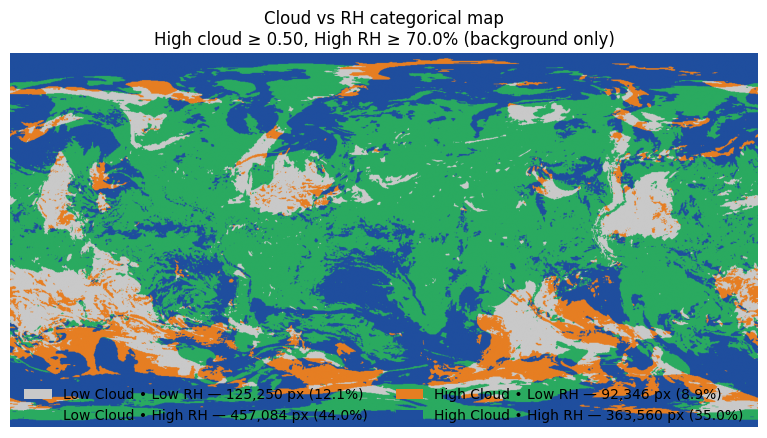

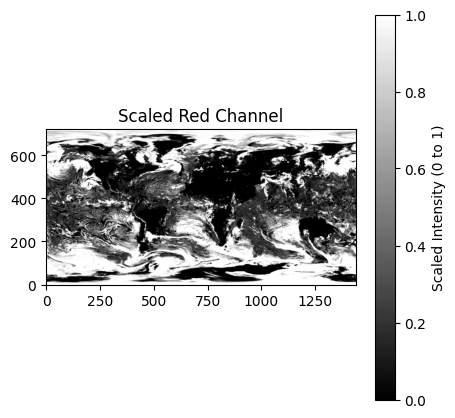

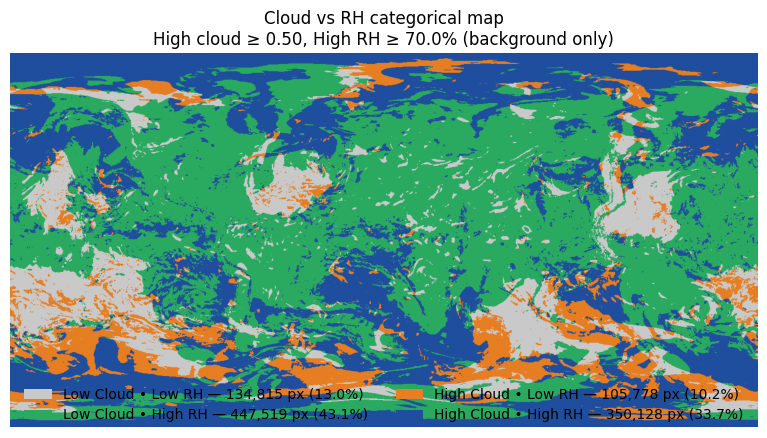

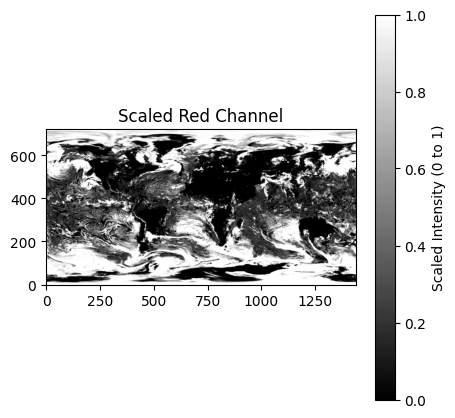

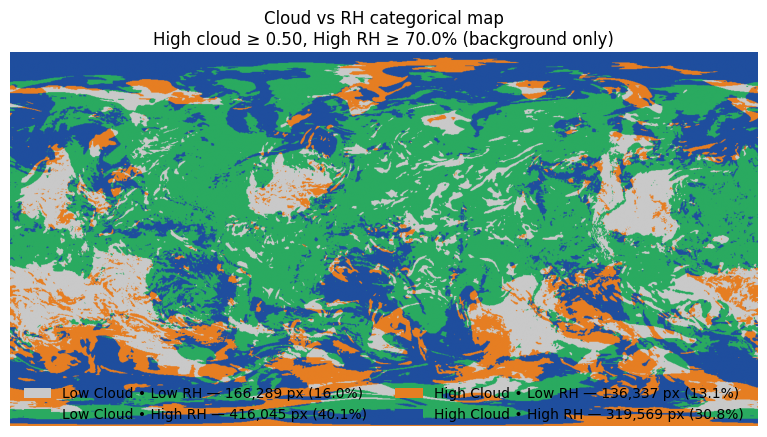

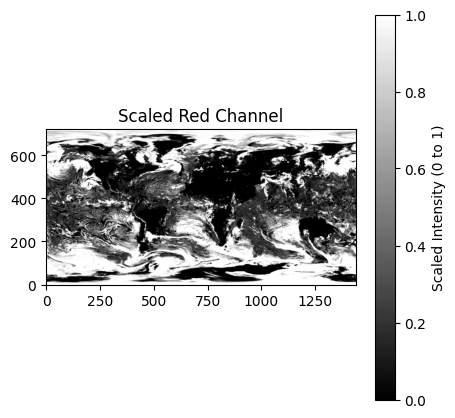

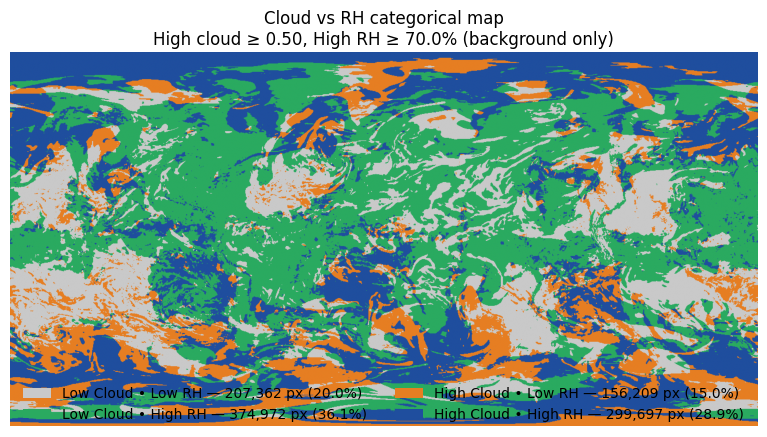

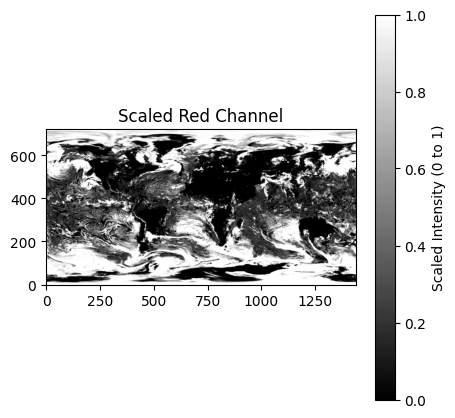

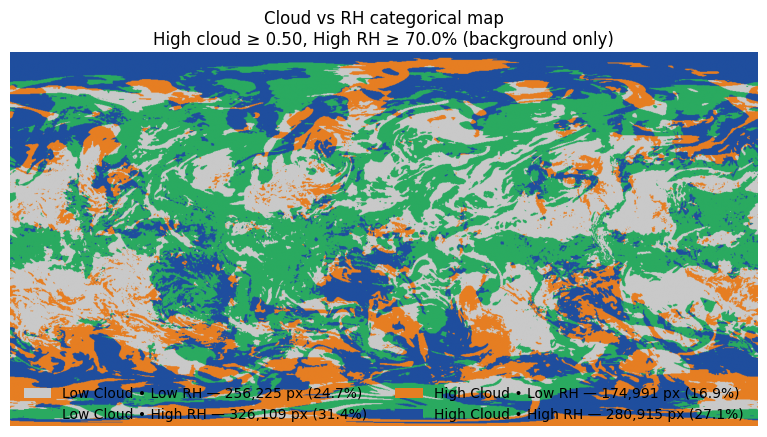

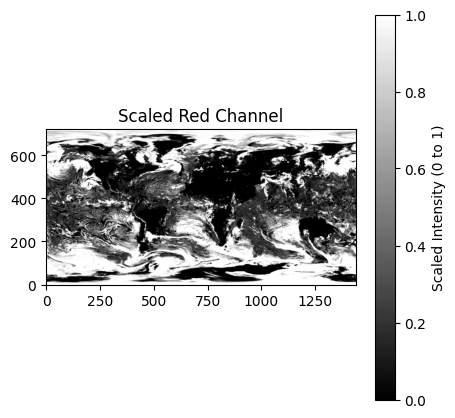

In [75]:
def plotRHToCloudCover(RH):
    # --- inputs from your notebook ---
    cloud  = np.asarray(scaled_red_channel)            # 0..1
    labels = np.asarray(result_array, dtype=np.uint8)  # 0 bg, 1 core, 2 neighbor
    RH = np.asarray(RH)
    # Optional land-sea mask (0 ocean, 1 land):
    # ocean_mask = (np.asarray(lsm) < 0.5)

    # --- analysis domain ---
    bg = (labels == 0)
    # If you want ocean-only:
    # bg &= ocean_mask

    # --- choose thresholds ---
    USE_QUANTILES = False

    if USE_QUANTILES:
        # robust thresholds from background pixels
        cloud_thr = np.nanpercentile(cloud[bg], 75)   # top quartile = “high cloud”
        rh_thr    = np.nanpercentile(RH[bg], 75)      # top quartile = “high RH”
    else:
        cloud_thr = 0.5  # fixed: “high cloud”
        rh_thr    = 70.0   # fixed: “high RH” in %

    # --- build categories (0..3) only on bg pixels; keep others transparent later ---
    # 0: low cloud, low RH      (LL) → light gray
    # 1: low cloud, high RH     (LH) → green
    # 2: high cloud, low RH     (HL) → orange
    # 3: high cloud, high RH    (HH) → deep blue
    cat = np.full(cloud.shape, -1, dtype=np.int8)  # -1 = not plotted (cores/neighbors)
    low_cloud = cloud < cloud_thr
    high_cloud = ~low_cloud
    low_rh = RH < rh_thr
    high_rh = ~low_rh

    # cat[np.where(bg & low_cloud & low_rh)]  = 0
    # cat[np.where(bg & low_cloud & high_rh)] = 1
    # cat[np.where(bg & high_cloud & low_rh)] = 2
    # cat[np.where(bg & high_cloud & high_rh)] = 3

    cat[np.where(low_cloud & low_rh)]  = 0
    cat[np.where(low_cloud & high_rh)] = 1
    cat[np.where(high_cloud & low_rh)] = 2
    cat[np.where(high_cloud & high_rh)] = 3

    # --- color map (colorblind-friendly, high contrast)
    cmap = ListedColormap([
        "#C9C9C9",  # 0 LL  light gray       (dry & clear)
        "#2AAA60",  # 1 LH  green            (humid but low cloud)
        "#E67E22",  # 2 HL  orange           (cloudy but drier)
        "#1F4E9E",  # 3 HH  deep blue        (wet & cloudy)
    ])

    # --- compute class counts for legend
    labels_text = [
        "Low Cloud • Low RH",
        "Low Cloud • High RH",
        "High Cloud • Low RH",
        "High Cloud • High RH",
    ]
    counts = [(cat == i).sum() for i in range(4)]
    total_bg = sum(counts)
    perc = [100*cnt/total_bg if total_bg>0 else 0 for cnt in counts]

    # --- make figure
    plt.figure(figsize=(8.5, 4.8))

    # background: show your gray cloud image faintly for context (optional)
    plt.imshow(cloud, origin="lower", cmap="gray", alpha=0.25)

    # categorical overlay (mask out cores/neighbors by setting alpha=0 for -1)
    # we’ll map -1 to transparent by plotting only valid categories
    valid = cat >= 0
    show = np.ma.masked_where(~valid, cat)
    # im = plt.imshow(show, origin="lower", cmap=cmap, vmin=-0.5, vmax=3.5)
    im = plt.imshow(cat, origin="lower", cmap=cmap, vmin=-0.5, vmax=3.5)

    plt.title(
        "Cloud vs RH categorical map\n"
        f"High cloud ≥ {cloud_thr:.2f}, High RH ≥ {rh_thr:.1f}% (background only)"
    )
    plt.axis("off")

    # custom legend with counts and %
    from matplotlib.patches import Patch
    handles = [
        Patch(facecolor=cmap.colors[i], edgecolor="none",
            label=f"{labels_text[i]} — {counts[i]:,} px ({perc[i]:.1f}%)")
        for i in range(4)
    ]
    plt.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
            ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()

def plotCloudCover():
    # Create a 2D plot from the scaled red channel array
    plt.figure(figsize=(5, 5))
    plt.imshow(scaled_red_channel, cmap='gray', origin='lower')
    plt.title('Scaled Red Channel')
    plt.colorbar(label='Scaled Intensity (0 to 1)')
    plt.show()

for i in range(1000, 850-1, -25):
    rh = rh_DS['r'].sel(isobaricInhPa=i)
    plotRHToCloudCover(rh)
    plotCloudCover()

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

CLOUD_CMAP = ListedColormap([
    "#C9C9C9",  # 0  Low Cloud • Downdraft/Low Wind
    "#2AAA60",  # 1  Low Cloud • Updraft/High Wind
    "#E67E22",  # 2  High Cloud • Downdraft/Low Wind
    "#1F4E9E",  # 3  High Cloud • Updraft/High Wind
])

def _legend(ax, labels, counts):
    total = int(sum(counts))
    perc = [100*cnt/total if total else 0 for cnt in counts]
    handles = [
        Patch(facecolor=CLOUD_CMAP.colors[i], edgecolor="none",
              label=f"{labels[i]} — {counts[i]:,} px ({perc[i]:.1f}%)")
        for i in range(4)
    ]
    ax.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
              ncol=2, frameon=False)


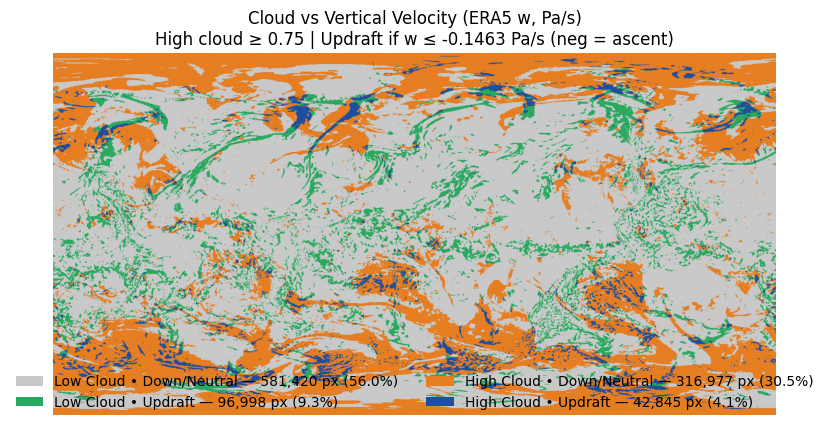

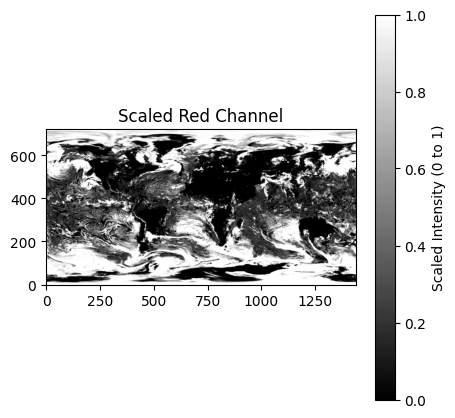

In [68]:
def plot_cloud_vs_w(
    cloud,              # 2D array, low cloud cover (0..1)
    w,                  # 2D array, vertical velocity (Pa/s for ERA5)
    cloud_thr=0.75,     # high cloud threshold
    w_thr=None,         # Pa/s magnitude; if None, auto from percentile of |w|
    w_thr_quantile=70,  # used when w_thr is None: e.g., 70th percentile of |w|
    include_gray_bg=True,
    title_prefix="Cloud vs Vertical Velocity (ERA5 w, Pa/s)"
):
    # thresholds
    if w_thr is None:
        w_thr = np.nanpercentile(np.abs(w), w_thr_quantile)
    # classify cloud
    high_cloud = cloud >= cloud_thr
    low_cloud  = ~high_cloud
    # classify vertical motion (binary): up if strong ascent, else down/neutral
    is_up   = (w <= -w_thr)
    is_down = ~is_up  # includes weak ascent, neutral, and subsidence

    # 4 categories
    cat = np.empty(cloud.shape, dtype=np.int8); cat.fill(-1)
    cat[ low_cloud &  is_down] = 0   # gray
    cat[ low_cloud &  is_up  ] = 1   # green
    cat[high_cloud &  is_down] = 2   # orange
    cat[high_cloud &  is_up  ] = 3   # blue

    # counts
    counts = [(cat == i).sum() for i in range(4)]

    # plot
    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    if include_gray_bg:
        ax.imshow(cloud, origin="lower", cmap="gray", alpha=0.25)
    im = ax.imshow(cat, origin="lower", cmap=CLOUD_CMAP, vmin=-0.5, vmax=3.5)
    ax.set_title(
        f"{title_prefix}\n"
        f"High cloud ≥ {cloud_thr:.2f} | Updraft if w ≤ -{w_thr:.4f} Pa/s "
        f"(neg = ascent)"
    )
    ax.axis("off")
    _legend(ax,
        ["Low Cloud • Down/Neutral", "Low Cloud • Updraft",
         "High Cloud • Down/Neutral", "High Cloud • Updraft"],
        counts
    )
    plt.tight_layout(); plt.show()
plot_cloud_vs_w(cloud, w_850, cloud_thr=0.75, w_thr=None, w_thr_quantile=70)
plotCloudCover()

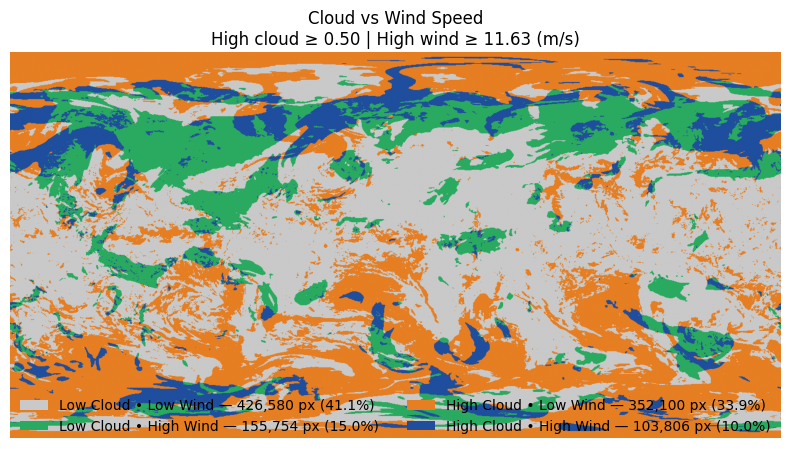

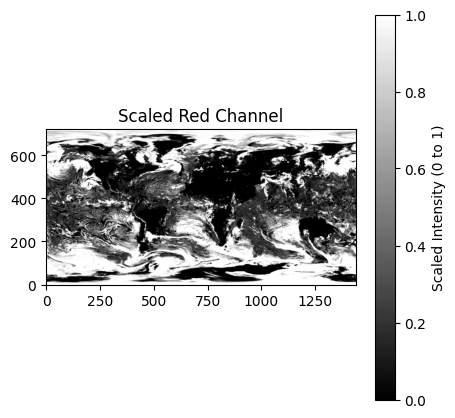

In [69]:
def plot_cloud_vs_winds(
    cloud, u, v,
    cloud_thr=0.75,
    speed_thr=None,         # if None, auto from percentile
    speed_thr_quantile=75,  # 75th percentile of speed
    include_gray_bg=True,
    title_prefix="Cloud vs Wind Speed"
):
    speed = np.hypot(u, v)
    if speed_thr is None:
        speed_thr = np.nanpercentile(speed, speed_thr_quantile)

    high_cloud = cloud >= cloud_thr
    low_cloud  = ~high_cloud
    high_wind  = speed >= speed_thr
    low_wind   = ~high_wind

    cat = np.empty(cloud.shape, dtype=np.int8); cat.fill(-1)
    cat[ low_cloud &  low_wind] = 0   # gray
    cat[ low_cloud & high_wind] = 1   # green
    cat[high_cloud &  low_wind] = 2   # orange
    cat[high_cloud & high_wind] = 3   # blue

    counts = [(cat == i).sum() for i in range(4)]

    fig, ax = plt.subplots(figsize=(8.8, 4.8))
    if include_gray_bg:
        ax.imshow(cloud, origin="lower", cmap="gray", alpha=0.25)
    im = ax.imshow(cat, origin="lower", cmap=CLOUD_CMAP, vmin=-0.5, vmax=3.5)
    ax.set_title(
        f"{title_prefix}\n"
        f"High cloud ≥ {cloud_thr:.2f} | High wind ≥ {speed_thr:.2f} (m/s)"
    )
    ax.axis("off")
    _legend(ax,
        ["Low Cloud • Low Wind", "Low Cloud • High Wind",
         "High Cloud • Low Wind", "High Cloud • High Wind"],
        counts
    )
    plt.tight_layout(); plt.show()
plot_cloud_vs_winds(cloud, u_850, v_850, cloud_thr=0.5, speed_thr=None, speed_thr_quantile=75)
plotCloudCover()


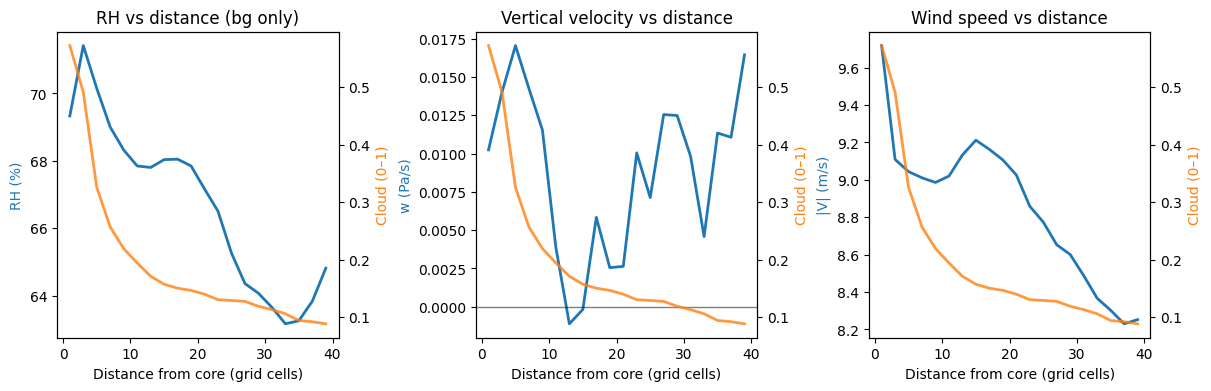

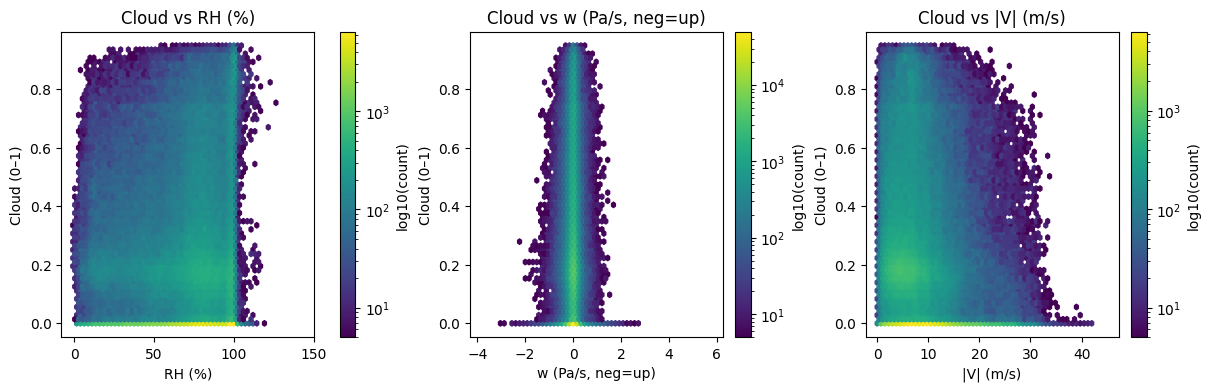

In [76]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

# --- Inputs you already have ---
cloud  = np.asarray(scaled_red_channel)          # 0..1 (LOW cloud cover)
labels = np.asarray(result_array, dtype=np.uint8)  # 0 bg, 1 core, 2 neighbor
RH     = np.asarray(r_850)                       # %  (or swap in your low-level proxy)
w      = np.asarray(w_850)                       # Pa/s (ERA5: negative = ascent)
u      = np.asarray(u_850)                       # m/s
v      = np.asarray(v_850)                       # m/s

# Optional: restrict to ocean only
# ocean_mask = (np.asarray(lsm) < 0.5)

def quick_edge_profiles(cloud, labels, RH, w, u, v, max_dist=40, step=2, ocean_mask=None):
    """
    Plot very simple, distance-from-core profiles for RH, w, and wind speed,
    overlaid with mean cloud cover. Background pixels only.
    """
    bg = (labels == 0)
    if ocean_mask is not None:
        bg &= ocean_mask

    # distance from nearest core (in grid cells)
    core = (labels == 1)
    dist = ndi.distance_transform_edt(~core)

    # bins and helper
    bins = np.arange(0, max_dist+step, step)
    centers = 0.5*(bins[:-1] + bins[1:])

    def prof(arr):
        x = dist[bg].ravel()
        y = arr[bg].ravel()
        idx = np.digitize(x, bins) - 1
        out = np.full(len(bins)-1, np.nan)
        for i in range(len(out)):
            sel = (idx == i)
            if np.any(sel):
                out[i] = np.nanmean(y[sel])
        return out

    windspeed = np.hypot(u, v)
    rh_m  = prof(RH)
    w_m   = prof(w)
    spd_m = prof(windspeed)
    cl_m  = prof(cloud)

    # plots
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)

    # RH vs distance + cloud overlay
    ax = axs[0]
    ax.plot(centers, rh_m, lw=2, label='RH (%)')
    ax.set_xlabel('Distance from core (grid cells)')
    ax.set_ylabel('RH (%)', color='C0')
    ax2 = ax.twinx()
    ax2.plot(centers, cl_m, lw=2, color='C1', alpha=0.8, label='Cloud')
    ax2.set_ylabel('Cloud (0–1)', color='C1')
    ax.set_title('RH vs distance (bg only)')

    # w vs distance + cloud overlay
    ax = axs[1]
    ax.plot(centers, w_m, lw=2, label='w (Pa/s)')
    ax.axhline(0, color='k', lw=1, alpha=0.5)
    ax.set_xlabel('Distance from core (grid cells)')
    ax.set_ylabel('w (Pa/s)', color='C0')  # neg = ascent
    ax2 = ax.twinx()
    ax2.plot(centers, cl_m, lw=2, color='C1', alpha=0.8)
    ax2.set_ylabel('Cloud (0–1)', color='C1')
    ax.set_title('Vertical velocity vs distance')

    # wind speed vs distance + cloud overlay
    ax = axs[2]
    ax.plot(centers, spd_m, lw=2, label='|V| (m/s)')
    ax.set_xlabel('Distance from core (grid cells)')
    ax.set_ylabel('|V| (m/s)', color='C0')
    ax2 = ax.twinx()
    ax2.plot(centers, cl_m, lw=2, color='C1', alpha=0.8)
    ax2.set_ylabel('Cloud (0–1)', color='C1')
    ax.set_title('Wind speed vs distance')

    plt.show()

def quick_scatter_grid(cloud, RH, w, u, v, labels, ocean_mask=None, sample=400000):
    """
    Simple hexbin: Cloud vs RH, Cloud vs w, Cloud vs wind speed.
    Background pixels only, with random subsample for speed.
    """
    bg = (labels == 0)
    if ocean_mask is not None:
        bg &= ocean_mask

    windspeed = np.hypot(u, v)

    # gather data
    Xs = [
        ('RH (%)', RH[bg].ravel()),
        ('w (Pa/s, neg=up)', w[bg].ravel()),
        ('|V| (m/s)', windspeed[bg].ravel()),
    ]
    Y = cloud[bg].ravel()

    # subsample for plotting
    rng = np.random.default_rng(0)
    ok = np.isfinite(Y)
    for name, X in Xs:
        ok &= np.isfinite(X)
    idx_all = np.where(ok)[0]
    if idx_all.size > sample:
        idx = rng.choice(idx_all, size=sample, replace=False)
    else:
        idx = idx_all

    # plot
    fig, axs = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
    for ax, (name, X) in zip(axs, Xs):
        hb = ax.hexbin(X[idx], Y[idx], gridsize=60, bins='log', mincnt=5)
        ax.set_xlabel(name)
        ax.set_ylabel('Cloud (0–1)')
        ax.set_title(f'Cloud vs {name}')
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label('log10(count)')
    plt.show()

# --- run them ---
quick_edge_profiles(cloud, labels, RH, w, u, v, max_dist=40, step=2)
quick_scatter_grid(cloud, RH, w, u, v, labels)
